In [25]:
import pandas as pd
import pyarrow.parquet as pq
import os

LOCAL_FILE = './rfsd/part-0.parquet'
SAMPLE_ROWS = 1000
SAMPLE_COLS = 20

print(f'Источник данных: {LOCAL_FILE}')
print(f'Целевой размер сэмпла: {SAMPLE_ROWS} строк x {SAMPLE_COLS} колонок')

Источник данных: ./rfsd/part-0.parquet
Целевой размер сэмпла: 1000 строк x 20 колонок


## 1. Чтение файла загруженного из huggingface

In [26]:
parquet_file = pq.ParquetFile(LOCAL_FILE)
all_columns = parquet_file.schema_arrow.names

print(f'Всего строк в файле: {parquet_file.metadata.num_rows:,}')
print(f'Всего колонок в файле: {len(all_columns)}')
print(f'Первые 15 колонок: {all_columns[:15]}')

Всего строк в файле: 3,170,560
Всего колонок в файле: 213
Первые 15 колонок: ['inn', 'ogrn', 'region', 'region_taxcode', 'creation_date', 'dissolution_date', 'age', 'eligible', 'exemption_criteria', 'financial', 'filed', 'imputed', 'simplified', 'articulated', 'totals_adjustment']


## 2. Сокращение до 20 колонок и 1000 строк

In [27]:
priority_columns = [
    'inn', 'ogrn', 'region', 'region_taxcode', 'okved', 'okved_section',
    'age', 'eligible', 'filed', 'imputed', 'outlier', 'simplified',
    'line_2110', 'line_2120', 'line_2200', 'line_2400',
    'line_1210', 'line_1300', 'line_1600', 'line_4100'
]

print(f'Выбрано {len(priority_columns)} колонок:')
print(priority_columns)

Выбрано 20 колонок:
['inn', 'ogrn', 'region', 'region_taxcode', 'okved', 'okved_section', 'age', 'eligible', 'filed', 'imputed', 'outlier', 'simplified', 'line_2110', 'line_2120', 'line_2200', 'line_2400', 'line_1210', 'line_1300', 'line_1600', 'line_4100']


In [28]:
batch = next(parquet_file.iter_batches(batch_size=SAMPLE_ROWS, columns=priority_columns))
df = batch.to_pandas()

print(f'Итоговый размер DataFrame: {df.shape}')
df.head()

Итоговый размер DataFrame: (1000, 20)


,inn,ogrn,region,region_taxcode,okved,okved_section,age,eligible,filed,imputed,outlier,simplified,line_2110,line_2120,line_2200,line_2400,line_1210,line_1300,line_1600,line_4100
0,NaN,9047796688213,moscow city,7700,46.21.14,G,20.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0100000011,1210100002353,adygeya,0100,56.10,I,3.0,1.0,1.0,0.0,0.0,1.0,65475.0,-63460.0,2015.0,39.0,3248.0,3091.0,5258.0,NaN
2,0100000043,1210100002364,adygeya,0100,94.99,S,3.0,1.0,1.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN
3,0100000068,1210100002375,adygeya,0100,68.32.20,L,3.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0100000075,1210100002386,adygeya,0100,96.09,S,3.0,1.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN


In [29]:
os.makedirs('output', exist_ok=True)
df.to_parquet('output/rfsd_sample.parquet', index=False)
df.to_csv('output/rfsd_sample.csv', index=False)
print('Выбранная часть сохранена в output/rfsd_sample.parquet и output/rfsd_sample.csv')

Выбранная часть сохранена в output/rfsd_sample.parquet и output/rfsd_sample.csv


## 3. Базовый анализ

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   inn             999 non-null    str    
 1   ogrn            1000 non-null   str    
 2   region          1000 non-null   str    
 3   region_taxcode  1000 non-null   str    
 4   okved           1000 non-null   str    
 5   okved_section   1000 non-null   str    
 6   age             1000 non-null   float64
 7   eligible        1000 non-null   float64
 8   filed           1000 non-null   float64
 9   imputed         1000 non-null   float64
 10  outlier         1000 non-null   float64
 11  simplified      732 non-null    float64
 12  line_2110       400 non-null    float64
 13  line_2120       428 non-null    float64
 14  line_2200       456 non-null    float64
 15  line_2400       498 non-null    float64
 16  line_1210       337 non-null    float64
 17  line_1300       660 non-null    float64
 18  

In [31]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing': missing, 'percent': missing_percent})

,missing,percent
line_4100,896,89.6
line_1210,663,66.3
line_2110,600,60.0
line_2120,572,57.2
line_2200,544,54.4
line_2400,502,50.2
line_1300,340,34.0
simplified,268,26.8
line_1600,268,26.8
inn,1,0.1


In [32]:
df.describe()

,age,eligible,filed,imputed,outlier,simplified,line_2110,line_2120,line_2200,line_2400,line_1210,line_1300,line_1600,line_4100
count,1000.000000,1000.00000,1000.000000,1000.0,1000.0,732.000000,4.000000e+02,4.280000e+02,456.000000,498.000000,3.370000e+02,6.600000e+02,7.320000e+02,1.040000e+02
mean,1.591000,0.96600,0.732000,0.0,0.0,0.494536,6.492535e+04,-4.926690e+04,5183.059211,1024.702811,4.417043e+04,7.639082e+06,6.962213e+06,-4.228457e+04
std,3.564327,0.18132,0.443139,0.0,0.0,0.500312,3.653131e+05,2.947439e+05,39142.736629,25746.046927,2.722263e+05,1.959781e+08,1.860883e+08,3.026285e+05
min,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.000000e+00,-3.886270e+06,-124288.000000,-215897.000000,0.000000e+00,-2.189190e+05,-8.700000e+01,-1.268759e+06
25%,0.000000,1.00000,0.000000,0.0,0.0,0.000000,7.230000e+02,-1.492250e+04,-67.000000,-90.500000,1.000000e+01,0.000000e+00,1.000000e+01,-3.759000e+03
50%,1.000000,1.00000,1.000000,0.0,0.0,0.000000,4.743500e+03,-3.006500e+03,111.000000,23.000000,4.070000e+02,1.000000e+01,4.910000e+02,-2.035000e+02
75%,2.000000,1.00000,1.000000,0.0,0.0,1.000000,2.284775e+04,-3.387500e+02,1356.750000,729.250000,3.179000e+03,7.727500e+02,6.190750e+03,1.245000e+02
max,32.000000,1.00000,1.000000,0.0,0.0,1.000000,5.106078e+06,0.000000e+00,683292.000000,352327.000000,3.783086e+06,5.034778e+09,5.034778e+09,1.518117e+06


## 4. Категории

In [33]:
for col in ['filed', 'outlier', 'imputed', 'simplified', 'eligible', 'okved_section']:
    if col in df.columns:
        print(f'\n--- {col} ---')
        print(df[col].value_counts(dropna=False).head(10))


--- filed ---
filed
1.0    732
0.0    268
Name: count, dtype: int64

--- outlier ---
outlier
0.0    1000
Name: count, dtype: int64

--- imputed ---
imputed
0.0    1000
Name: count, dtype: int64

--- simplified ---
simplified
0.0    370
1.0    362
NaN    268
Name: count, dtype: int64

--- eligible ---
eligible
1.0    966
0.0     34
Name: count, dtype: int64

--- okved_section ---
okved_section
G    187
F    155
C     94
M     72
S     67
N     67
H     54
L     51
Q     45
I     44
Name: count, dtype: int64


In [34]:
if 'region' in df.columns:
    print('Топ-10 регионов:')
    print(df['region'].value_counts().head(10))

Топ-10 регионов:
region
adygeya        989
krasnodar        7
moscow city      2
ingushetia       1
kalmykia         1
Name: count, dtype: int64


## 5. Корреляционный анализ

In [35]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr().round(2)
corr

,age,eligible,filed,imputed,outlier,simplified,line_2110,line_2120,line_2200,line_2400,line_1210,line_1300,line_1600,line_4100
age,1.00,0.08,0.01,NaN,NaN,-0.12,0.38,-0.38,0.40,0.35,0.04,0.00,0.00,0.13
eligible,0.08,1.00,-0.11,NaN,NaN,0.04,0.02,-0.03,0.03,0.01,0.03,0.01,0.01,-0.02
filed,0.01,-0.11,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imputed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
outlier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
simplified,-0.12,0.04,NaN,NaN,NaN,1.00,-0.14,0.13,-0.08,0.00,-0.14,-0.04,-0.04,0.01
line_2110,0.38,0.02,NaN,NaN,NaN,-0.14,1.00,-0.99,0.79,0.60,0.67,0.67,0.49,0.10
line_2120,-0.38,-0.03,NaN,NaN,NaN,0.13,-0.99,1.00,-0.75,-0.60,-0.53,-0.65,-0.66,-0.07
line_2200,0.40,0.03,NaN,NaN,NaN,-0.08,0.79,-0.75,1.00,0.65,0.02,0.63,0.31,0.23
line_2400,0.35,0.01,NaN,NaN,NaN,0.00,0.60,-0.60,0.65,1.00,-0.17,0.71,-0.14,0.32


## 6. Диаграммы для выручки, чистой прибыли и активов

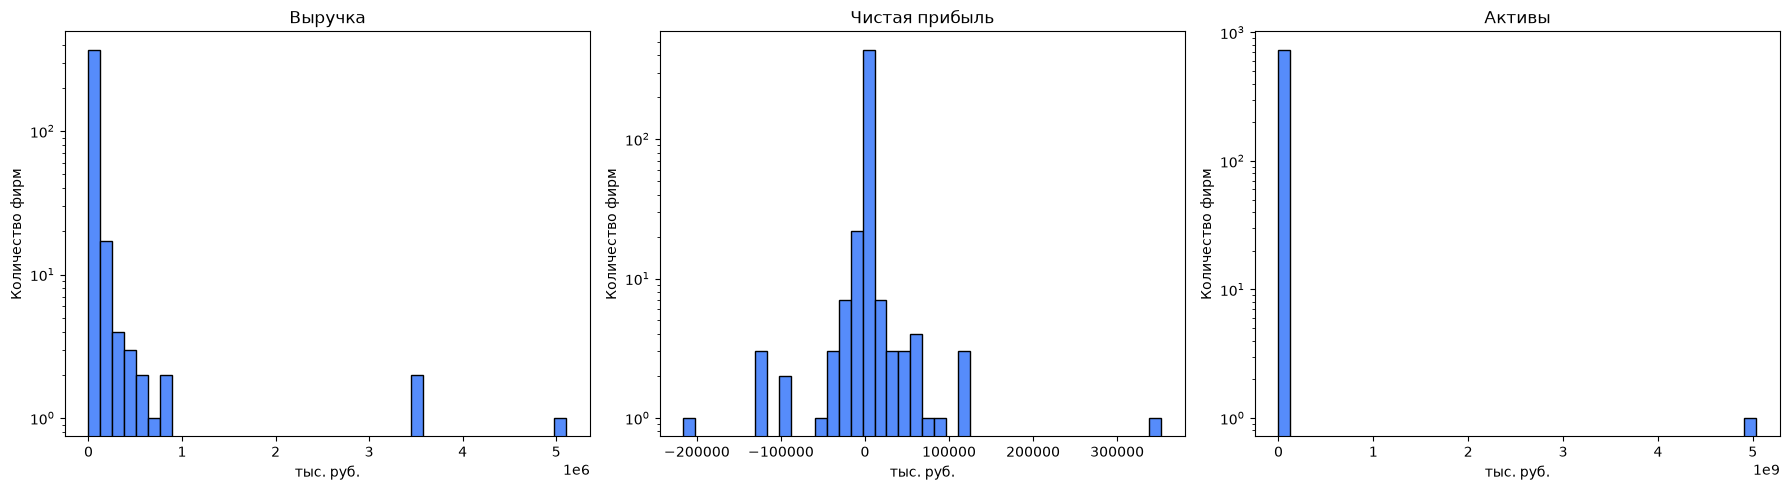


Выручка (line_2110):
  Непустых значений: 400
  Допустимый диапазон от -32,464.12 до 56,034.88
  Количество выбросов: 57
  Минимум: 0.00; максимум: 5,106,078.00

Чистая прибыль (line_2400):
  Непустых значений: 498
  Допустимый диапазон от -1,320.12 до 1,958.88
  Количество выбросов: 122
  Минимум: -215,897.00; максимум: 352,327.00

Активы (line_1600):
  Непустых значений: 732
  Допустимый диапазон от -9,261.12 до 15,461.88
  Количество выбросов: 121
  Минимум: -87.00; максимум: 5,034,778,059.00


In [36]:
import matplotlib.pyplot as plt

hist_columns = {
    'line_2110': 'Выручка',
    'line_2400': 'Чистая прибыль',
    'line_1600': 'Активы'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (column, title) in zip(axes, hist_columns.items()):
    values = df[column].dropna()
    ax.hist(values, bins=40, edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('тыс. руб.')
    ax.set_ylabel('Количество фирм')
    ax.set_yscale('log')

plt.tight_layout()
plt.show()

for column, title in hist_columns.items():
    values = df[column].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = values[(values < lower_bound) | (values > upper_bound)]

    print(f'\n{title} ({column}):')
    print(f'  Непустых значений: {len(values)}')
    print(f'  Допустимый диапазон от {lower_bound:,.2f} до {upper_bound:,.2f}')
    print(f'  Количество выбросов: {len(outliers)}')
    print(f'  Минимум: {values.min():,.2f}; максимум: {values.max():,.2f}')

In [37]:
# Выручка. Найдено 57 выбросов среди 400 непустых значений. Максимальная выручка равна 5 106 078 тыс. руб., что значительно превышает верхнюю границу. Такое значение может принадлежать крупной компании.
# Чистая прибыль. Найдено 122 выброса среди 498 значений. Показатель меняется от −215 897 до 352 327 тыс. руб., тогда как диапазон IQR составляет примерно от −1 320 до 1 959 тыс. руб. Большие положительные значения и убытки могут быть реальными
# Активы. Найден 121 выброс среди 732 значений. Максимальное значение — 5 034 778 059 тыс. руб. очень большое. Отрицательная сумма выглядит как некорректное или ошибочно значение.

## 7. Матрица корреляции между всеми 20 колонками

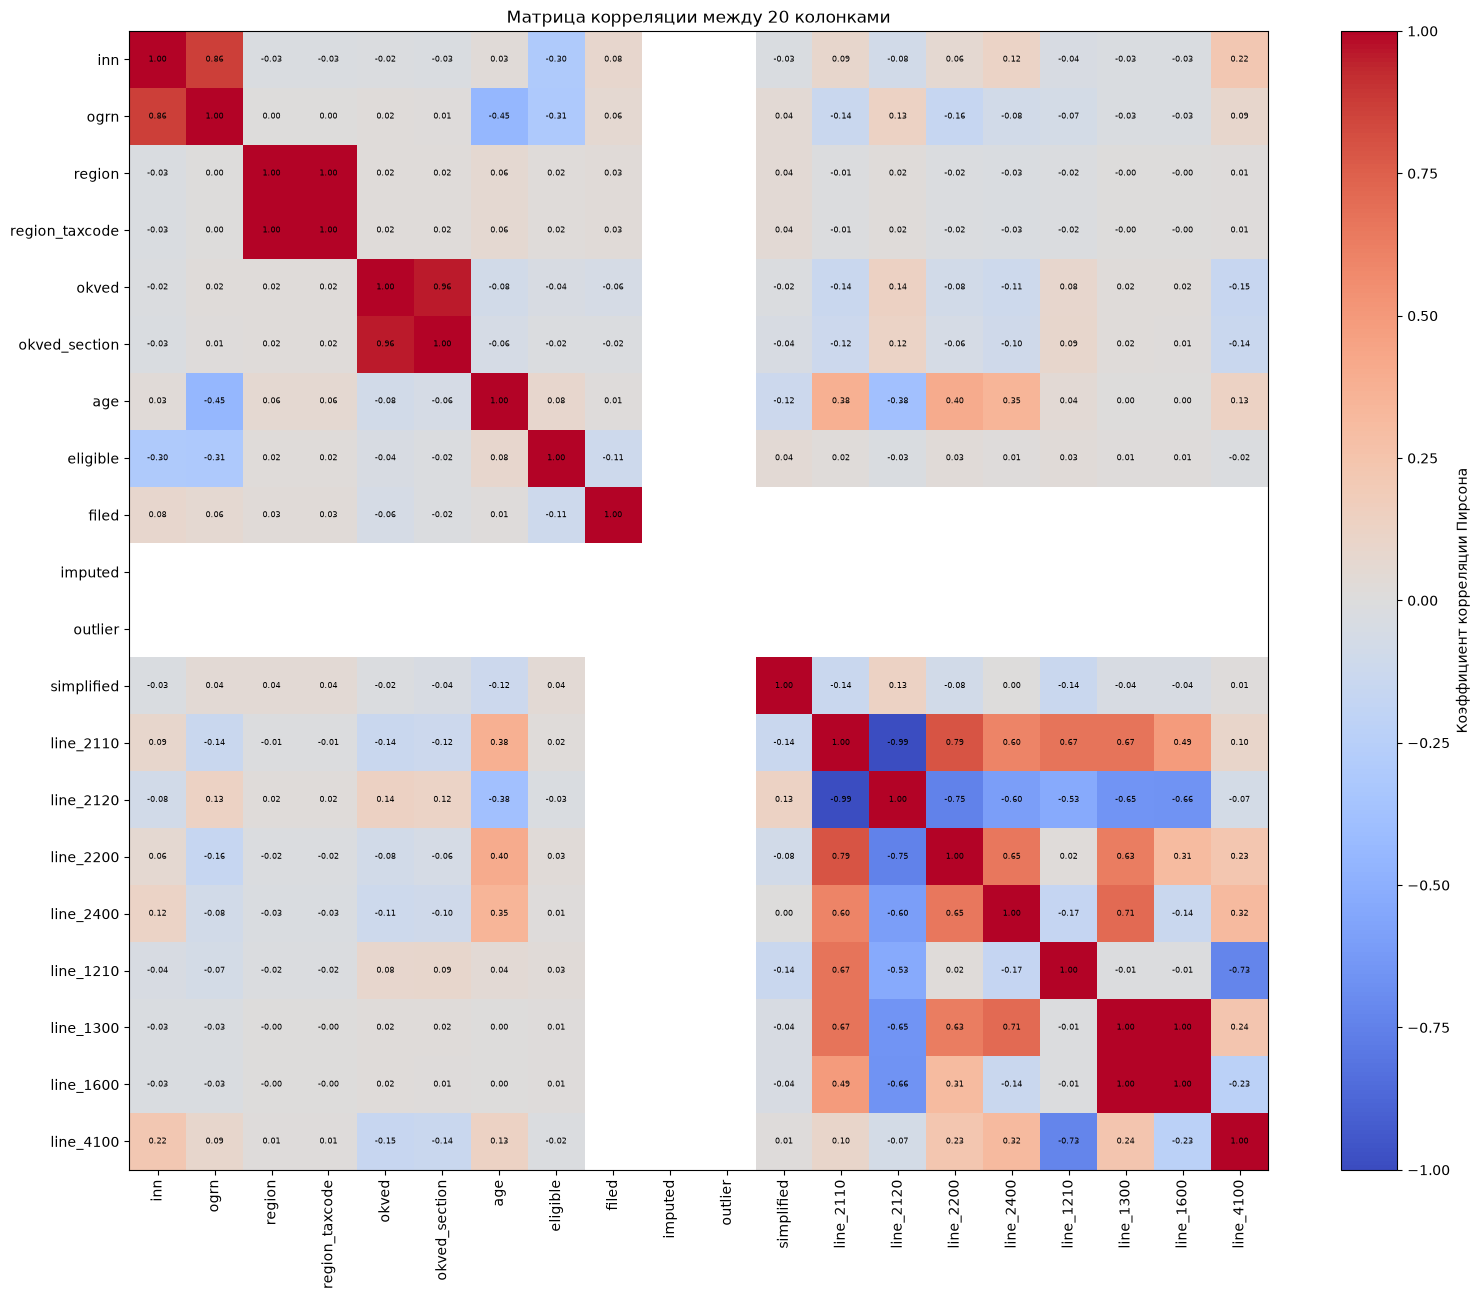

,Колонка 1,Колонка 2,Корреляция
0,region,region_taxcode,1.00
1,line_1300,line_1600,1.00
2,line_2110,line_2120,-0.99
3,okved,okved_section,0.96
4,inn,ogrn,0.86
5,line_2110,line_2200,0.79
6,line_2120,line_2200,-0.75
7,line_1210,line_4100,-0.73
8,line_2400,line_1300,0.71


In [38]:
import matplotlib.pyplot as plt

correlation_df = df.copy()
categorical_columns = correlation_df.select_dtypes(exclude='number').columns

for column in categorical_columns:
    codes = pd.Categorical(correlation_df[column]).codes.astype(float)
    codes[df[column].isna()] = float('nan')
    correlation_df[column] = codes

corr_all = correlation_df.corr().round(2)

plt.figure(figsize=(16, 13))
image = plt.imshow(corr_all, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(image, label='Коэффициент корреляции Пирсона')
plt.xticks(range(len(corr_all.columns)), corr_all.columns, rotation=90)
plt.yticks(range(len(corr_all.columns)), corr_all.columns)

for row in range(len(corr_all)):
    for column in range(len(corr_all.columns)):
        value = corr_all.iloc[row, column]
        if pd.notna(value):
            plt.text(column, row, f'{value:.2f}', ha='center', va='center', fontsize=6)

plt.title('Матрица корреляции между 20 колонками')
plt.tight_layout()
plt.show()

high_correlations = []
for i in range(len(corr_all.columns)):
    for j in range(i + 1, len(corr_all.columns)):
        value = corr_all.iloc[i, j]
        if pd.notna(value) and abs(value) >= 0.7:
            high_correlations.append((corr_all.columns[i], corr_all.columns[j], value))

high_correlations = sorted(high_correlations, key=lambda item: abs(item[2]), reverse=True)
pd.DataFrame(high_correlations, columns=['Колонка 1', 'Колонка 2', 'Корреляция'])

### Интерпретация корреляции

Высокой считаем корреляцию, значение не меньше 0,7. Обнаружены связи:

- **`region` — `region_taxcode` (1,00)**: обе колонки описывают один и тот же регион
- **`line_1300` — `line_1600` (1,00)**: капитал связан с величиной активов.
- **`line_2110` — `line_2120` (−0,99)**: при росте выручки обычно растёт себестоимость.
- **`okved` — `okved_section` (0,96)**: секция ОКВЭД определяется кодом ОКВЭД.
- **`inn` — `ogrn` (0,87)**: ИНН и ОГРН являются идентификаторами, они некорреляцируются.
- **`line_2110` — `line_2200` (0,79)** и **`line_2120` — `line_2200` (−0,75)**: прибыль от продаж рассчитывается на основе выручки и себестоимости
- **`line_1210` — `line_4100` (−0,73)**: запасы, уменьшают денежные средства.
- **`line_2400` — `line_1300` (0,72)**: прибыль увеличивает собственный капитал.

## 8. Диаграмма рассеивания

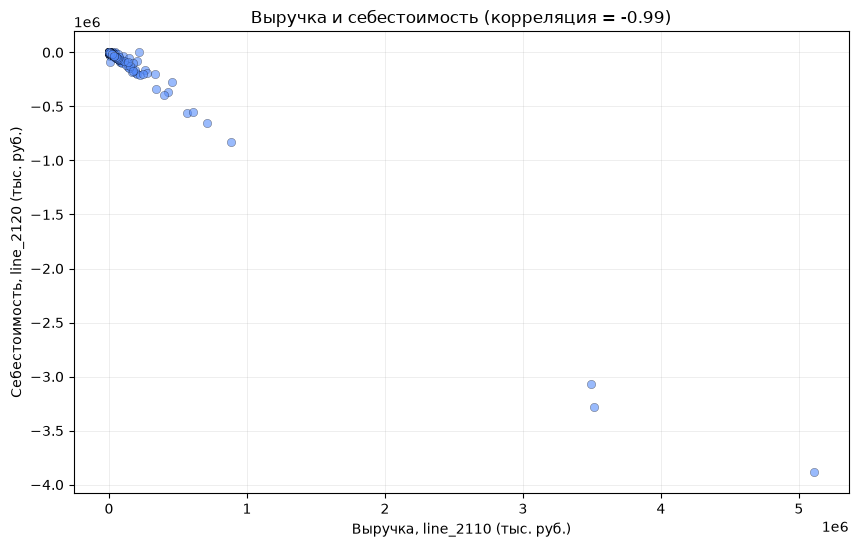

In [39]:
scatter_data = df[['line_2110', 'line_2120']].dropna()
correlation = scatter_data['line_2110'].corr(scatter_data['line_2120'])

plt.figure(figsize=(10, 6))
plt.scatter(
    scatter_data['line_2110'],
    scatter_data['line_2120'],
    alpha=0.6,
    edgecolors='black',
    linewidths=0.3
)
plt.title(f'Выручка и себестоимость (корреляция = {correlation:.2f})')
plt.xlabel('Выручка, line_2110 (тыс. руб.)')
plt.ylabel('Себестоимость, line_2120 (тыс. руб.)')
plt.grid(alpha=0.3)
plt.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
plt.show()

In [40]:
### Вывод

# На диаграмме точки располагаются вдоль нисходящей линии, что подтверждает сильную отрицательную корреляцию между выручкой и
# себестоимостью. Чем выше выручка компании, тем больше её расходы на производство и продажу товаров.